In [3]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\annaconda1.o\lib\site-packages\object_detection-0.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\annaconda1.o\lib\site-packages\pyparsing-2.4.7-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\annaconda1.o\lib\site-packages\sacrebleu-2.2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [75]:
#pip install pandas numpy matplotlib seaborn scikit-learn

In [76]:
import pandas as pd

Data from Survey

In [77]:
df = pd.read_csv("../data/water_consumption_forecasting.csv")

df.head()

,region,date,consumption_liters
0,North,2023-01-01,11673.07
1,North,2023-01-02,14736.03
2,North,2023-01-03,19370.75
3,North,2023-01-04,17774.55
4,North,2023-01-05,14972.58


In [78]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   region              900 non-null    object 
 1   date                900 non-null    object 
 2   consumption_liters  900 non-null    float64
dtypes: float64(1), object(2)
memory usage: 21.2+ KB


,consumption_liters
count,900.000000
mean,12753.758211
std,4278.566391
min,5004.090000
25%,9187.247500
50%,13045.510000
75%,16365.062500
max,19989.830000


In [79]:
#Creating Week field 

In [104]:
df['Date'] = pd.to_datetime(df['date'])

df = df.sort_values('Date')
df = df.drop(['date'], axis=1)

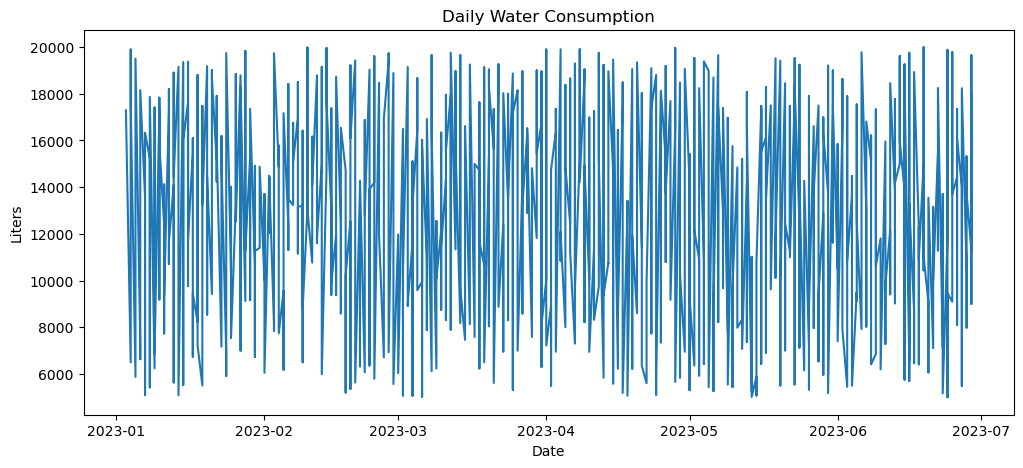

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['consumption_liters'])
plt.title("Daily Water Consumption")
plt.xlabel("Date")
plt.ylabel("Liters")
plt.show()

In [106]:
df.head()

,consumption_liters,Date,day_of_week,month,week_of_year,is_weekend,lag_1,lag_2,lag_7,lag_14,rolling_3,rolling_7,rolling_14,region_East,region_North,region_South,region_West
362,17286.15,2023-01-03,1,1,1,0,8483.00,12415.60,10106.33,11673.07,12728.250000,15233.822857,13312.135000,True,False,False,False
543,6499.03,2023-01-04,2,1,1,0,17286.15,8483.00,14736.03,14250.36,10756.060000,14057.108571,12758.468571,False,False,False,True
723,9499.28,2023-01-04,2,1,1,0,6499.03,17286.15,15984.70,7670.67,11094.820000,13130.620000,12889.083571,False,False,False,False
183,19892.74,2023-01-04,2,1,1,0,9499.28,6499.03,18360.53,14490.80,11963.683333,13349.507143,13274.936429,False,False,True,False
3,17774.55,2023-01-04,2,1,1,0,19892.74,9499.28,19370.75,17241.79,15722.190000,13121.478571,13312.990714,False,True,False,False


In [107]:
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['week_of_year'] = df['Date'].dt.isocalendar().week

In [108]:
df = df.drop(['Date'], axis=1)
df.head()

,consumption_liters,day_of_week,month,week_of_year,is_weekend,lag_1,lag_2,lag_7,lag_14,rolling_3,rolling_7,rolling_14,region_East,region_North,region_South,region_West
362,17286.15,1,1,1,0,8483.00,12415.60,10106.33,11673.07,12728.250000,15233.822857,13312.135000,True,False,False,False
543,6499.03,2,1,1,0,17286.15,8483.00,14736.03,14250.36,10756.060000,14057.108571,12758.468571,False,False,False,True
723,9499.28,2,1,1,0,6499.03,17286.15,15984.70,7670.67,11094.820000,13130.620000,12889.083571,False,False,False,False
183,19892.74,2,1,1,0,9499.28,6499.03,18360.53,14490.80,11963.683333,13349.507143,13274.936429,False,False,True,False
3,17774.55,2,1,1,0,19892.74,9499.28,19370.75,17241.79,15722.190000,13121.478571,13312.990714,False,True,False,False


In [109]:
#Now dataset understands calendar patterns
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
df.head()

,consumption_liters,day_of_week,month,week_of_year,is_weekend,lag_1,lag_2,lag_7,lag_14,rolling_3,rolling_7,rolling_14,region_East,region_North,region_South,region_West
362,17286.15,1,1,1,0,8483.00,12415.60,10106.33,11673.07,12728.250000,15233.822857,13312.135000,True,False,False,False
543,6499.03,2,1,1,0,17286.15,8483.00,14736.03,14250.36,10756.060000,14057.108571,12758.468571,False,False,False,True
723,9499.28,2,1,1,0,6499.03,17286.15,15984.70,7670.67,11094.820000,13130.620000,12889.083571,False,False,False,False
183,19892.74,2,1,1,0,9499.28,6499.03,18360.53,14490.80,11963.683333,13349.507143,13274.936429,False,False,True,False
3,17774.55,2,1,1,0,19892.74,9499.28,19370.75,17241.79,15722.190000,13121.478571,13312.990714,False,True,False,False


In [110]:
df['lag_1'] = df['consumption_liters'].shift(1)
df['lag_2'] = df['consumption_liters'].shift(2)
df['lag_7'] = df['consumption_liters'].shift(7)
df['lag_14'] = df['consumption_liters'].shift(14)
# lag_1  -> yesterday usage
# lag_7  -> same day last week
# lag_14 -> two weeks ago

In [111]:
#Rolling Feature(capture's Trend)
df['rolling_3'] = df['consumption_liters'].rolling(3).mean()
df['rolling_7'] = df['consumption_liters'].rolling(7).mean()
df['rolling_14'] = df['consumption_liters'].rolling(14).mean()

In [113]:
df = df.dropna()

In [114]:
df = df[(df["consumption_liters"] > 1000) & (df["consumption_liters"] < 30000)]

In [116]:
X = df.drop(['consumption_liters'], axis=1)
y = df['consumption_liters']

Train Model

In [117]:
#pip install xgboost

In [118]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [119]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [126]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [128]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 868.7566574776785


In [129]:
#Make Prediction
predictions = model.predict(X_test)

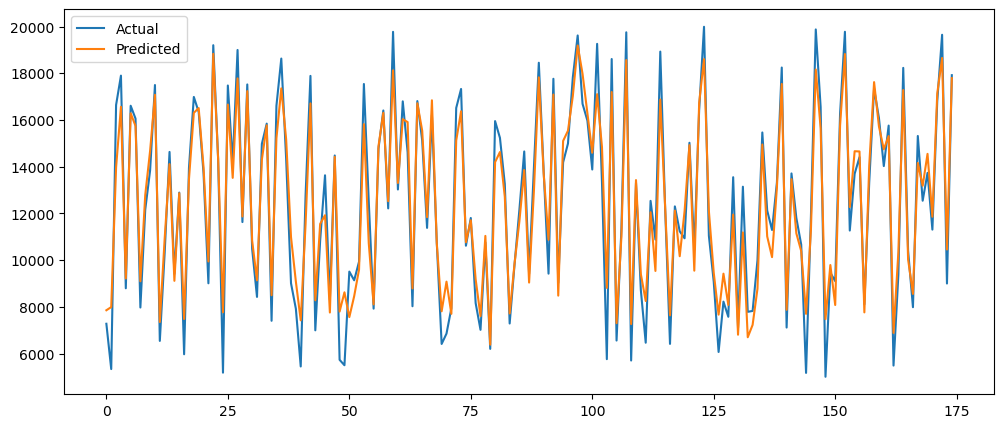

In [130]:
#Visualize Prediction
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.show()

In [131]:
df.head()

,consumption_liters,day_of_week,month,week_of_year,is_weekend,lag_1,lag_2,lag_7,lag_14,rolling_3,rolling_7,rolling_14,region_East,region_North,region_South,region_West
725,6632.12,4,1,1,0,8077.63,12210.80,7036.06,17286.15,8973.516667,11581.941429,11804.522143,False,False,False,False
545,18149.98,4,1,1,0,6632.12,8077.63,12398.24,6499.03,10953.243333,12403.618571,12636.732857,False,False,False,True
726,13596.90,5,1,1,1,18149.98,6632.12,14972.58,9499.28,12793.000000,12207.092857,12929.420000,False,False,False,False
546,5093.36,5,1,1,1,13596.90,18149.98,19496.84,19892.74,12280.080000,10149.452857,11872.321429,False,False,False,True
6,12822.42,5,1,1,1,5093.36,13596.90,7285.38,17774.55,10504.226667,10940.458571,11518.597857,False,True,False,False


Saving the model

In [133]:
import joblib

joblib.dump(model, "../models/water_forecast_model.pkl")

['../models/water_forecast_model.pkl']

In [134]:
# %load ../main.py
import joblib 
import pandas as pd

model = joblib.load("../models/water_forecast_model.pkl")
def predict_tomorrow(input_data):

    df = pd.DataFrame([input_data])

    prediction = model.predict(df)

    return prediction[0]
    
input_data = {
    "day_of_week":2,
    "month":3,
    "week_of_year":12,
    "is_weekend":0,
    "lag_1":12000,
    "lag_2":11500,
    "lag_7":11800,
    "lag_14":11000,
    "rolling_3":11800,
    "rolling_7":11750,
    "rolling_14":11600,
    "region_East":0,
    "region_North":1,
    "region_South":0,
    "region_West":0
}
    
prediction = predict_tomorrow(input_data)

print("Predicted Water Consumption Tomorrow:", prediction, "liters")

Predicted Water Consumption Tomorrow: 12210.782 liters
